# LSTM / BiLSTM / GRU on landmark sequences 

Classifies gestures from MediaPipe landmark sequences `(T, 63)` into 13 classes.

1. Load extracted landmarks
2. Subject-wise train/validation split
3. Choose `T_fixed` and build loaders
4. Baseline BiLSTM
5. Architecture comparison: LSTM vs BiLSTM vs GRU
6. Hyperparameter experiments
7. Final evaluation, inference speed, error analysis

Unlike the classical models, the sequence is **not** flattened - the RNN reads it frame by frame,
which is the whole point of using a temporal model here.

## 1. Setup

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from src.data.dataset import load_train_test, GESTURE_NAMES
from src.evaluation.metrics import full_evaluation, measure_inference_time, compare_models
from src.models.landmark_dataset import (
    load_landmark_split, attach_video_names, subject_wise_split,
    build_loaders, compute_class_weights,
)
from src.models.lstm_model import GestureRNN
from src.models.rnn_train_utils import (
    train_model, predict, set_seed, get_device, count_parameters,
)

sns.set_theme(style="whitegrid")
set_seed(42)

DATA_DIR = "../raw_data/raw"
LANDMARKS_TRAIN = "../data/landmarks/train"
LANDMARKS_TEST = "../data/landmarks/test"
RESULTS_DIR = "../results/figures"

# Set to True for a fast smoke test, False for the real runs
QUICK_RUN = False
EPOCHS = 15 if QUICK_RUN else 50
EPOCHS_EXP = 10 if QUICK_RUN else 20
PATIENCE = 5 if QUICK_RUN else 8

device = get_device()
print("device:", device)

device: cpu


/home/jovana/video-hand-gesture-recognition/.venv/lib/python3.10/site-packages/torch/cuda/__init__.py:188: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 11040). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /__w/pytorch/pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


## 2. Load landmark sequences

Gestures with almost no detected frames are dropped - a 2-frame sequence carries no motion
information and only adds noise.

In [2]:
train_df, test_df = load_train_test(DATA_DIR)

train_seqs, train_labels, train_meta = load_landmark_split(
    LANDMARKS_TRAIN, min_frames=5, min_detection_rate=0.3)
test_seqs, test_labels, test_meta = load_landmark_split(
    LANDMARKS_TEST, min_frames=5, min_detection_rate=0.3)

print(f"train sequences: {len(train_seqs)}")
print(f"test sequences:  {len(test_seqs)}")
print(f"feature dim:     {train_seqs[0].shape[1]}")
print(f"length range:    {min(len(s) for s in train_seqs)} - {max(len(s) for s in train_seqs)} frames")

Train: 3117 gestures (from 4039 with non-gesture)
Test:  1101 gestures (from 1610 with non-gesture)
Classes: 13 gestures
train sequences: 3104
test sequences:  1101
feature dim:     63
length range:    9 - 621 frames


## 3. Subject-wise train/validation split

IPN Hand video names follow `{scene}_{subject}_{hand}_#{video}`, so `1CM1_4_R_#229`
belongs to subject `1CM1_4`. The first token alone is only the scene - dozens of
different people share it, so grouping by it would collapse ~37 subjects into 4.

Splitting randomly would put the same person in both sets, and the model would partly
recognise the *person* instead of the *gesture* - validation accuracy would look great
and test accuracy would collapse.

In [3]:
train_meta = attach_video_names(train_meta, train_df)
tr_mask, va_mask = subject_wise_split(train_meta, val_fraction=0.2, seed=42)

tr_seqs = [train_seqs[i] for i in np.where(tr_mask)[0]]
tr_labels = train_labels[tr_mask]
va_seqs = [train_seqs[i] for i in np.where(va_mask)[0]]
va_labels = train_labels[va_mask]

print(f"train: {len(tr_seqs)} samples, {train_meta['subject'][tr_mask].nunique()} subjects")
print(f"val:   {len(va_seqs)} samples, {train_meta['subject'][va_mask].nunique()} subjects")
print("overlap:", set(train_meta['subject'][tr_mask]) & set(train_meta['subject'][va_mask]))

train: 2515 samples, 30 subjects
val:   589 samples, 7 subjects
overlap: set()


## 4. Choosing `T_fixed`

Durations are bimodal: dynamic gestures (Click, Throw, Zoom) last ~50 frames, static
Point gestures 150-300. The 75th percentile (191) would pad ~75% of sequences and
triple the compute per batch.

`T_fixed = 60` covers the dynamic mode with little padding. Longer gestures are
uniformly subsampled, not truncated, so a 250-frame Point still spans the whole gesture
at lower temporal resolution - fine for a static hold. Section 9 tests this empirically.

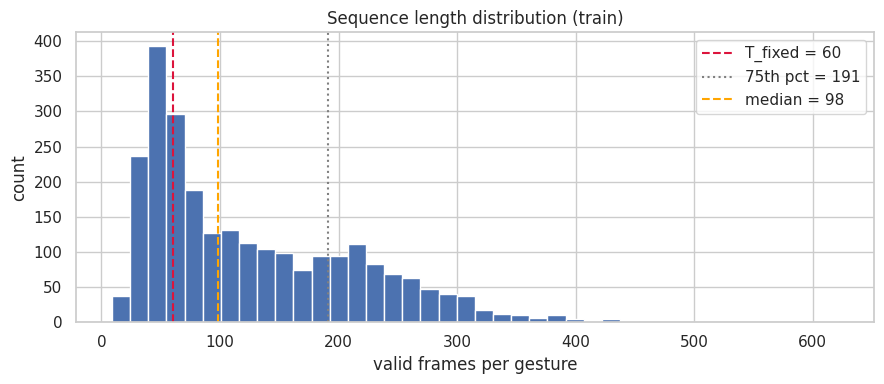

T_fixed = 60
padded (shorter):    31.3%
subsampled (longer): 67.5%


In [4]:
lengths = np.array([len(s) for s in tr_seqs])
T_FIXED = 60   

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(lengths, bins=40, color="#4C72B0", edgecolor='white')
ax.axvline(T_FIXED, color='crimson', linestyle='--', label=f'T_fixed = {T_FIXED}')
ax.axvline(np.percentile(lengths, 75), color='gray', linestyle=':', label=f'75th pct = {np.percentile(lengths, 75):.0f}')
ax.axvline(np.median(lengths), color='orange', linestyle='--', label=f'median = {np.median(lengths):.0f}')
ax.set_xlabel('valid frames per gesture'); ax.set_ylabel('count')
ax.set_title('Sequence length distribution (train)'); ax.legend()
plt.tight_layout(); plt.show()

print(f"T_fixed = {T_FIXED}")
print(f"padded (shorter):    {(lengths < T_FIXED).mean():.1%}")
print(f"subsampled (longer): {(lengths > T_FIXED).mean():.1%}")

## 5. Class weights

`Point-1f` and `Point-2f` dominate the dataset. Without weighting, predicting only those two
already gives a decent accuracy, so the model never learns the rare gestures.
Inverse-frequency weights in the loss fix that.

In [5]:
class_weights = compute_class_weights(tr_labels)

counts = np.bincount(tr_labels, minlength=13)
weights_df = pd.DataFrame({
    'gesture': GESTURE_NAMES,
    'samples': counts,
    'loss_weight': class_weights.numpy().round(3),
}).sort_values('samples', ascending=False)
print(weights_df.to_string(index=False))

    gesture  samples  loss_weight
   Point-1f      605        0.320
   Point-2f      598        0.324
   Throw-up      120        1.612
Throw-right      120        1.612
 Throw-left      120        1.612
 Open-twice      120        1.612
DblClick-2f      120        1.612
 Throw-down      119        1.626
   Click-1f      119        1.626
   Zoom-out      119        1.626
DblClick-1f      119        1.626
   Click-2f      118        1.640
    Zoom-in      118        1.640


## 6. Data loaders

Two preprocessing choices worth noting:

- **velocity features**: frame-to-frame differences are appended, `(T, 63) -> (T, 126)`.
  Position encodes hand *shape*, velocity encodes *motion* - and `Throw-up` vs `Throw-down`
  differ almost only in motion direction.
- **standardisation**: mean/std are fitted on the training split only, then applied to
  val and test. Fitting on everything would leak test statistics into training.

In [6]:
BATCH_SIZE = 64
USE_VELOCITY = True

train_loader, val_loader, test_loader = build_loaders(
    tr_seqs, tr_labels, va_seqs, va_labels, test_seqs, test_labels,
    t_fixed=T_FIXED, batch_size=BATCH_SIZE, use_velocity=USE_VELOCITY)

INPUT_SIZE = 126 if USE_VELOCITY else 63

xb, yb, lb = next(iter(train_loader))
print(f"batch x: {tuple(xb.shape)}   (batch, T_fixed, features)")
print(f"batch y: {tuple(yb.shape)}   lengths: {lb.min().item()}-{lb.max().item()}")

batch x: (64, 60, 126)   (batch, T_fixed, features)
batch y: (64,)   lengths: 28-60


## 7. Baseline BiLSTM

Padding is handled with `pack_padded_sequence`, so the classifier reads each gesture's real
last frame instead of a run of zeros. This matters a lot here, since many sequences are
much shorter than `T_fixed`.

In [7]:
set_seed(42)

baseline = GestureRNN(
    input_size=INPUT_SIZE, hidden_size=128, num_layers=2,
    rnn_type='lstm', bidirectional=True, dropout=0.3)

print(f"parameters: {count_parameters(baseline):,}")

baseline_metrics, baseline_time = train_model(
    baseline, train_loader, val_loader, class_weights=class_weights,
    epochs=EPOCHS, lr=1e-3, patience=PATIENCE)

parameters: 674,701
  epoch   1  train 2.418/0.134   val 2.207/0.261
  epoch   5  train 0.875/0.715   val 1.136/0.722
  epoch  10  train 0.488/0.841   val 0.928/0.803
  epoch  15  train 0.331/0.895   val 1.310/0.772
  epoch  20  train 0.162/0.960   val 0.954/0.823
  epoch  25  train 0.107/0.977   val 1.063/0.825
  epoch  30  train 0.088/0.982   val 1.018/0.835
  epoch  35  train 0.073/0.983   val 1.035/0.829
  early stopping at epoch 35
  best val loss 0.9857 / accuracy 0.8387  (1371s)


### Training curves

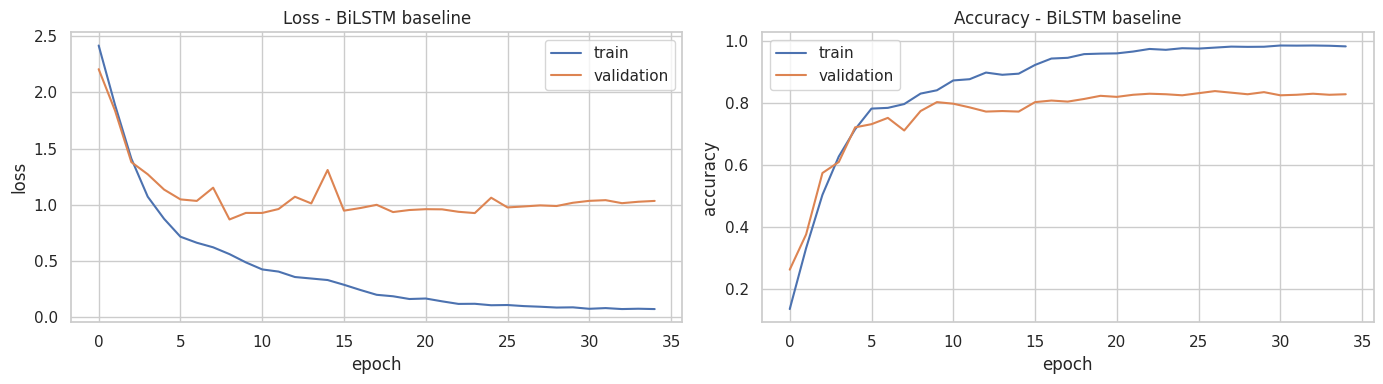

In [8]:
def plot_curves(metrics, title):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes[0].plot(metrics['train_loss'], label='train')
    axes[0].plot(metrics['val_loss'], label='validation')
    axes[0].set_xlabel('epoch'); axes[0].set_ylabel('loss'); axes[0].legend()
    axes[0].set_title(f'Loss - {title}')

    axes[1].plot(metrics['train_acc'], label='train')
    axes[1].plot(metrics['val_acc'], label='validation')
    axes[1].set_xlabel('epoch'); axes[1].set_ylabel('accuracy'); axes[1].legend()
    axes[1].set_title(f'Accuracy - {title}')
    plt.tight_layout(); plt.show()

plot_curves(baseline_metrics, 'BiLSTM baseline')

## 8. Architecture comparison: LSTM vs BiLSTM vs GRU

- **LSTM** reads the gesture forwards only.
- **BiLSTM** reads it forwards and backwards - for an isolated clip the ending is as
  informative as the beginning, so this usually wins.
- **GRU** has fewer gates (2 instead of 3), so it is smaller and trains faster.

All four are trained under identical settings (hidden=128, 2 layers, dropout 0.3, same
seed), so the only difference is the architecture itself.

In [9]:
ARCHITECTURES = {
    'LSTM':   dict(rnn_type='lstm', bidirectional=False),
    'BiLSTM': dict(rnn_type='lstm', bidirectional=True),
    'GRU':    dict(rnn_type='gru',  bidirectional=False),
    'BiGRU':  dict(rnn_type='gru',  bidirectional=True),
}

arch_results = {}
for name, kwargs in ARCHITECTURES.items():
    print(f"\n--- {name} ---")
    set_seed(42)
    model = GestureRNN(input_size=INPUT_SIZE, hidden_size=128, num_layers=2,
                       dropout=0.3, **kwargs)
    m, t = train_model(model, train_loader, val_loader, class_weights=class_weights,
                       epochs=EPOCHS_EXP, patience=PATIENCE, verbose=False)
    arch_results[name] = {
        'model': model, 'metrics': m, 'train_time': t,
        'val_acc': m['best_val_acc'], 'params': count_parameters(model),
    }
    print(f"val acc {m['best_val_acc']:.4f} | {count_parameters(model):,} params | {t:.0f}s")


--- LSTM ---
val acc 0.7606 | 272,269 params | 366s

--- BiLSTM ---
val acc 0.8234 | 674,701 params | 711s

--- GRU ---
val acc 0.8014 | 206,477 params | 177s

--- BiGRU ---
val acc 0.8183 | 510,349 params | 428s


architecture  val_accuracy  parameters  train_time_s
      BiLSTM      0.823430      674701           711
       BiGRU      0.818336      510349           428
         GRU      0.801358      206477           177
        LSTM      0.760611      272269           366


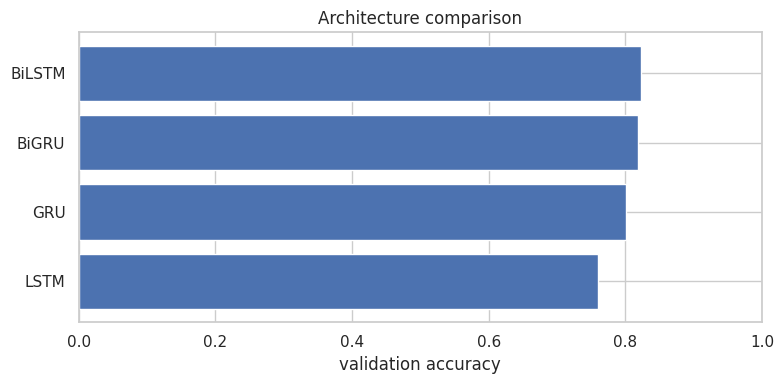

In [10]:
arch_df = pd.DataFrame([{
    'architecture': k,
    'val_accuracy': v['val_acc'],
    'parameters': v['params'],
    'train_time_s': round(v['train_time']),
} for k, v in arch_results.items()]).sort_values('val_accuracy', ascending=False)

print(arch_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(arch_df['architecture'], arch_df['val_accuracy'], color="#4C72B0")
ax.set_xlabel('validation accuracy'); ax.set_xlim(0, 1)
ax.set_title('Architecture comparison'); ax.invert_yaxis()
plt.tight_layout(); plt.show()

Bidirectional variants win in both families (BiLSTM +6.3 points over LSTM, BiGRU +1.7
over GRU), confirming that the end of an isolated clip carries as much information as
its start.

GRU is the efficiency winner: fewer parameters (206k vs 272k), half the training time,
*and* higher accuracy than LSTM. With only 2515 training samples, the simpler gating
appears to overfit less. BiLSTM stays the most accurate overall, but GRU reaches 97% of
that accuracy with a third of the parameters - relevant for the real-time use case.

## 9. Hyperparameter experiments

Only one factor is changed at a time, keeping the best architecture fixed, so each result
is attributable to that single change.

In [11]:
BEST_ARCH = arch_df.iloc[0]['architecture']
best_kwargs = ARCHITECTURES[BEST_ARCH]
print(f"tuning on: {BEST_ARCH}")

experiments = []

# 9a. hidden size
for hidden in [64, 128, 256]:
    set_seed(42)
    model = GestureRNN(input_size=INPUT_SIZE, hidden_size=hidden, num_layers=2,
                       dropout=0.3, **best_kwargs)
    m, t = train_model(model, train_loader, val_loader, class_weights=class_weights,
                       epochs=EPOCHS_EXP, patience=PATIENCE, verbose=False)
    experiments.append({'experiment': 'hidden_size', 'value': hidden,
                        'val_accuracy': m['best_val_acc'], 'params': count_parameters(model)})
    print(f"hidden={hidden:3d}  val acc {m['best_val_acc']:.4f}")

tuning on: BiLSTM
hidden= 64  val acc 0.7878
hidden=128  val acc 0.8234
hidden=256  val acc 0.8285


In [12]:
# 9b. number of layers
for layers in [1, 2, 3]:
    set_seed(42)
    model = GestureRNN(input_size=INPUT_SIZE, hidden_size=128, num_layers=layers,
                       dropout=0.3, **best_kwargs)
    m, t = train_model(model, train_loader, val_loader, class_weights=class_weights,
                       epochs=EPOCHS_EXP, patience=PATIENCE, verbose=False)
    experiments.append({'experiment': 'num_layers', 'value': layers,
                        'val_accuracy': m['best_val_acc'], 'params': count_parameters(model)})
    print(f"layers={layers}  val acc {m['best_val_acc']:.4f}")

layers=1  val acc 0.7691
layers=2  val acc 0.8234
layers=3  val acc 0.8234


In [13]:
# 9c. dropout
for dr in [0.2, 0.3, 0.5]:
    set_seed(42)
    model = GestureRNN(input_size=INPUT_SIZE, hidden_size=128, num_layers=2,
                       dropout=dr, **best_kwargs)
    m, t = train_model(model, train_loader, val_loader, class_weights=class_weights,
                       epochs=EPOCHS_EXP, patience=PATIENCE, verbose=False)
    experiments.append({'experiment': 'dropout', 'value': dr,
                        'val_accuracy': m['best_val_acc'], 'params': count_parameters(model)})
    print(f"dropout={dr}  val acc {m['best_val_acc']:.4f}")

dropout=0.2  val acc 0.8217
dropout=0.3  val acc 0.8234
dropout=0.5  val acc 0.7793


In [14]:
# 9d. learning rate
for lr_try in [1e-3, 5e-4, 1e-4]:
    set_seed(42)
    model = GestureRNN(input_size=INPUT_SIZE, hidden_size=128, num_layers=2,
                       dropout=0.3, **best_kwargs)
    m, t = train_model(model, train_loader, val_loader, class_weights=class_weights,
                       epochs=EPOCHS_EXP, lr=lr_try, patience=PATIENCE, verbose=False)
    experiments.append({'experiment': 'learning_rate', 'value': lr_try,
                        'val_accuracy': m['best_val_acc'], 'params': count_parameters(model)})
    print(f"lr={lr_try:g}  val acc {m['best_val_acc']:.4f}")

lr=0.001  val acc 0.8234
lr=0.0005  val acc 0.8081
lr=0.0001  val acc 0.7538


### Does `T_fixed` matter?

Longer sequences give more context but more padding for short gestures.

In [15]:
for t_try in [30, T_FIXED, 120]:
    loaders = build_loaders(tr_seqs, tr_labels, va_seqs, va_labels,
                            test_seqs, test_labels, t_fixed=t_try,
                            batch_size=BATCH_SIZE, use_velocity=USE_VELOCITY)
    set_seed(42)
    model = GestureRNN(input_size=INPUT_SIZE, hidden_size=128, num_layers=2,
                       dropout=0.3, **best_kwargs)
    m, t = train_model(model, loaders[0], loaders[1], class_weights=class_weights,
                       epochs=EPOCHS_EXP, patience=PATIENCE, verbose=False)
    experiments.append({'experiment': 'T_fixed', 'value': t_try,
                        'val_accuracy': m['best_val_acc'], 'params': count_parameters(model)})
    print(f"T_fixed={t_try:3d}  val acc {m['best_val_acc']:.4f}")

T_fixed= 30  val acc 0.8081
T_fixed= 60  val acc 0.8234
T_fixed=120  val acc 0.7929


### Do velocity features help?

This isolates the contribution of the motion features added in step 6.

In [16]:
for use_vel in [False, True]:
    loaders = build_loaders(tr_seqs, tr_labels, va_seqs, va_labels,
                            test_seqs, test_labels, t_fixed=T_FIXED,
                            batch_size=BATCH_SIZE, use_velocity=use_vel)
    set_seed(42)
    model = GestureRNN(input_size=126 if use_vel else 63, hidden_size=128,
                       num_layers=2, dropout=0.3, **best_kwargs)
    m, t = train_model(model, loaders[0], loaders[1], class_weights=class_weights,
                       epochs=EPOCHS_EXP, patience=PATIENCE, verbose=False)
    experiments.append({'experiment': 'velocity_features', 'value': use_vel,
                        'val_accuracy': m['best_val_acc'], 'params': count_parameters(model)})
    print(f"velocity={use_vel}  val acc {m['best_val_acc']:.4f}")

velocity=False  val acc 0.7725
velocity=True  val acc 0.8234


       experiment   value  val_accuracy  params
      hidden_size      64      0.787776  206733
      hidden_size     128      0.823430  674701
      hidden_size     256      0.828523 2397069
       num_layers       1      0.769100  279437
       num_layers       2      0.823430  674701
       num_layers       3      0.823430 1069965
          dropout     0.2      0.821732  674701
          dropout     0.3      0.823430  674701
          dropout     0.5      0.779287  674701
    learning_rate   0.001      0.823430  674701
    learning_rate  0.0005      0.808149  674701
    learning_rate  0.0001      0.753820  674701
          T_fixed      30      0.808149  674701
          T_fixed      60      0.823430  674701
          T_fixed     120      0.792869  674701
velocity_features   False      0.772496  610189
velocity_features    True      0.823430  674701


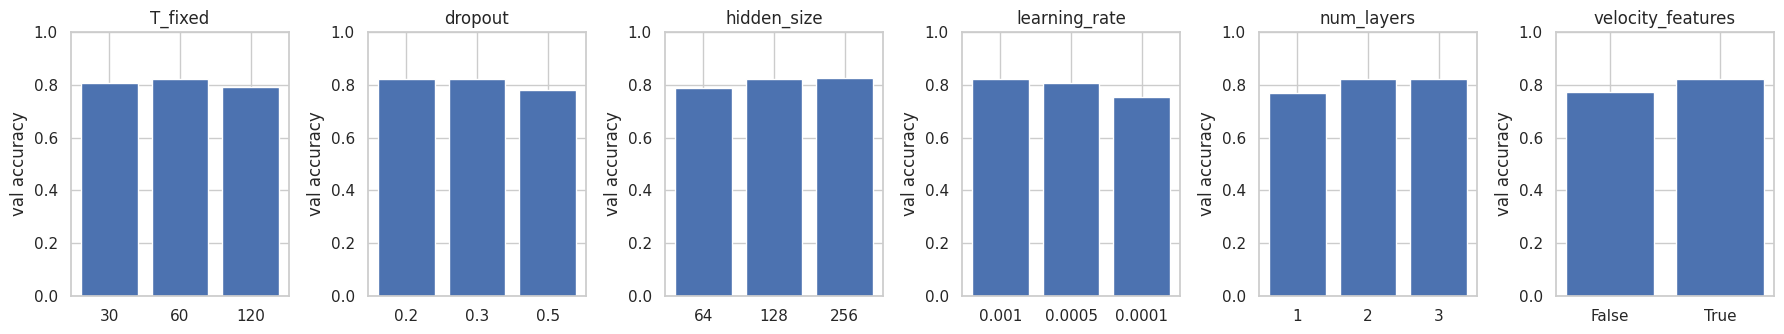

In [17]:
exp_df = pd.DataFrame(experiments)
print(exp_df.to_string(index=False))

fig, axes = plt.subplots(1, len(exp_df['experiment'].unique()), figsize=(18, 3.5))
for ax, (name, grp) in zip(np.atleast_1d(axes), exp_df.groupby('experiment')):
    ax.bar(grp['value'].astype(str), grp['val_accuracy'], color="#4C72B0")
    ax.set_title(name); ax.set_ylabel('val accuracy'); ax.set_ylim(0, 1)
plt.tight_layout(); plt.show()

## 10. Final model

The best configuration found above is retrained and evaluated on the **test split**, which
has not been touched until now.

architecture: BiLSTM
hidden=128, layers=2, dropout=0.3, T_fixed=60
  epoch   1  train 2.418/0.134   val 2.207/0.261
  epoch   5  train 0.875/0.715   val 1.136/0.722
  epoch  10  train 0.488/0.841   val 0.928/0.803
  epoch  15  train 0.331/0.895   val 1.310/0.772
  epoch  20  train 0.162/0.960   val 0.954/0.823
  epoch  25  train 0.107/0.977   val 1.063/0.825
  epoch  30  train 0.088/0.982   val 1.018/0.835
  epoch  35  train 0.073/0.983   val 1.035/0.829
  early stopping at epoch 35
  best val loss 0.9857 / accuracy 0.8387  (1722s)


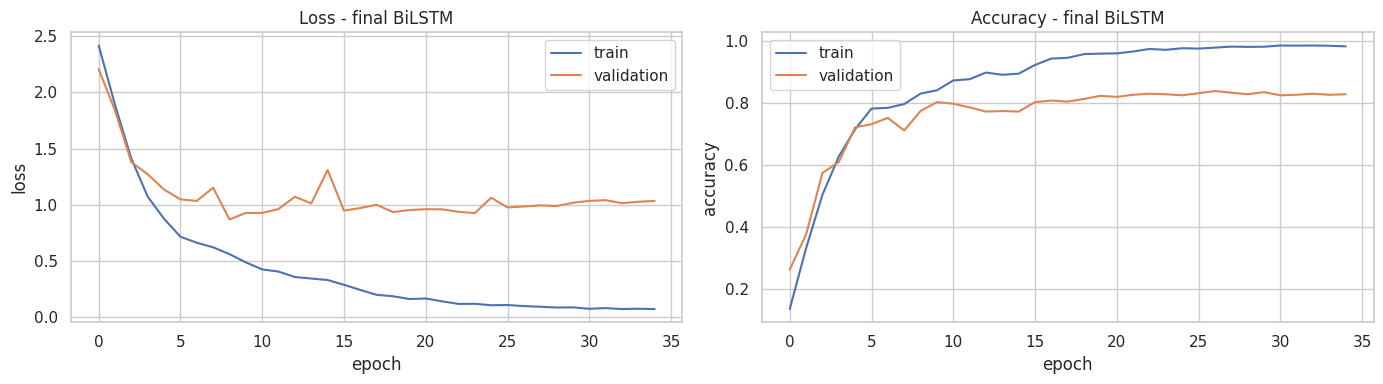

In [18]:
# hidden 256 wins by only +0.005 accuracy but needs 3.5x the parameters (2.4M vs 675k),
# so the smaller model is preferred - the difference is within run-to-run noise
best_hidden = 128
best_layers = int(exp_df[exp_df['experiment'] == 'num_layers']
                  .sort_values('val_accuracy', ascending=False).iloc[0]['value'])
best_dropout = float(exp_df[exp_df['experiment'] == 'dropout']
                     .sort_values('val_accuracy', ascending=False).iloc[0]['value'])
best_t = int(exp_df[exp_df['experiment'] == 'T_fixed']
             .sort_values('val_accuracy', ascending=False).iloc[0]['value'])

print(f"architecture: {BEST_ARCH}")
print(f"hidden={best_hidden}, layers={best_layers}, dropout={best_dropout}, T_fixed={best_t}")

train_loader, val_loader, test_loader = build_loaders(
    tr_seqs, tr_labels, va_seqs, va_labels, test_seqs, test_labels,
    t_fixed=best_t, batch_size=BATCH_SIZE, use_velocity=USE_VELOCITY)

set_seed(42)
final_model = GestureRNN(input_size=INPUT_SIZE, hidden_size=best_hidden,
                         num_layers=best_layers, dropout=best_dropout, **best_kwargs)
final_metrics, final_time = train_model(
    final_model, train_loader, val_loader, class_weights=class_weights,
    epochs=EPOCHS, patience=PATIENCE)

plot_curves(final_metrics, f'final {BEST_ARCH}')

## 11. Evaluation

All models are scored with the shared `full_evaluation()` from `src/evaluation/metrics.py`,
so these numbers are directly comparable with the classical models and the 3D CNN.

### 11.1 Test set metrics

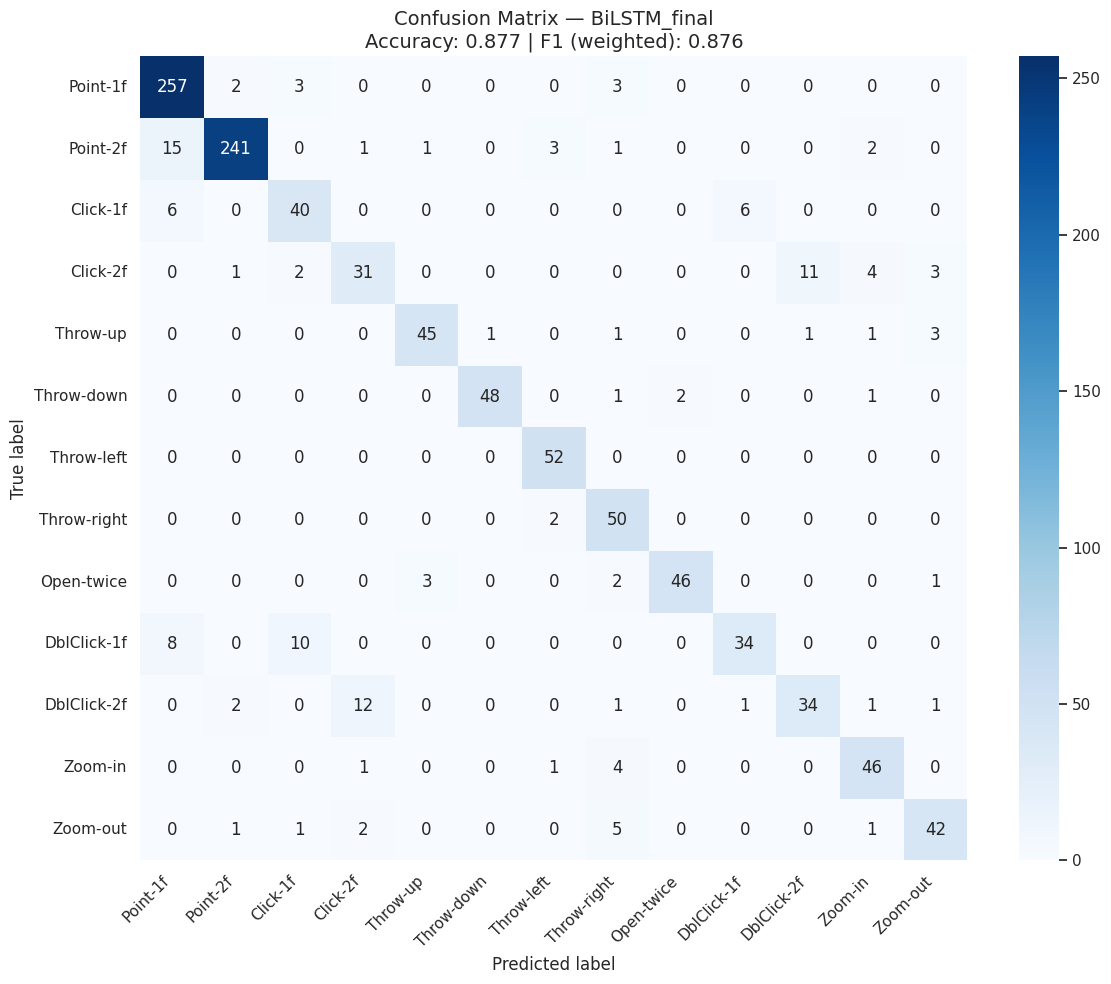

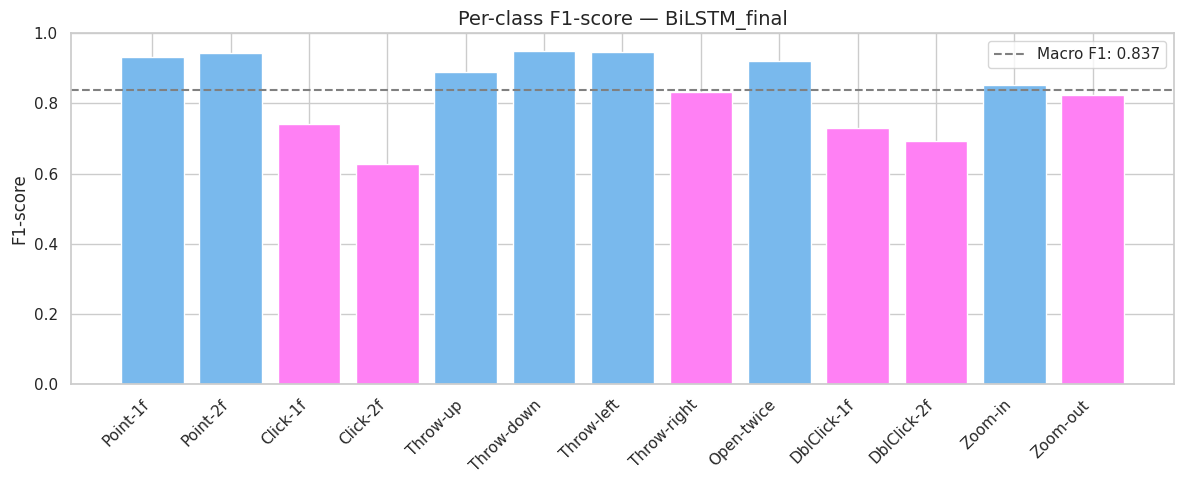


  BiLSTM_final — Results
  Accuracy:          0.8774
  F1 (weighted):     0.8761
  F1 (macro):        0.8372
  Precision (w):     0.8796
  Recall (w):        0.8774
  Top-3 Accuracy:    0.9737
  Top-5 Accuracy:    0.9855

              precision    recall  f1-score   support

    Point-1f       0.90      0.97      0.93       265
    Point-2f       0.98      0.91      0.94       264
    Click-1f       0.71      0.77      0.74        52
    Click-2f       0.66      0.60      0.63        52
    Throw-up       0.92      0.87      0.89        52
  Throw-down       0.98      0.92      0.95        52
  Throw-left       0.90      1.00      0.95        52
 Throw-right       0.74      0.96      0.83        52
  Open-twice       0.96      0.88      0.92        52
 DblClick-1f       0.83      0.65      0.73        52
 DblClick-2f       0.74      0.65      0.69        52
     Zoom-in       0.82      0.88      0.85        52
    Zoom-out       0.84      0.81      0.82        52

    accuracy       

In [19]:
y_true, y_pred, y_prob = predict(final_model, test_loader)

final_results = full_evaluation(
    y_true, y_pred, model_name=f"{BEST_ARCH}_final",
    save_dir=RESULTS_DIR, y_prob=y_prob)

### 11.2 Inference speed

Relevant for the real-time demo: the model has to keep up with the webcam.

In [20]:
single = next(iter(test_loader))
x_one = single[0][:1]
len_one = single[2][:1]

def predict_one(x):
    with torch.no_grad():
        return final_model(x.to(device), len_one)

final_model.to(device).eval()
timing = measure_inference_time(predict_one, x_one, n_runs=100)
print(f"inference: {timing['mean_ms']:.2f} ms/sample  (+/- {timing['std_ms']:.2f})  "
      f"-> {timing['fps']:.0f} samples/s")

inference: 1.86 ms/sample  (+/- 2.89)  -> 538 samples/s


### 11.3 Error analysis

Which gestures does the model actually confuse, and does that make sense?

In [21]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred, labels=range(13))
np.fill_diagonal(cm, 0)

pairs = []
for i in range(13):
    for j in range(13):
        if cm[i, j] > 0:
            pairs.append({'true': GESTURE_NAMES[i], 'predicted': GESTURE_NAMES[j],
                          'count': int(cm[i, j])})

top_conf = pd.DataFrame(pairs).sort_values('count', ascending=False).head(10)
print("Most confused pairs:")
print(top_conf.to_string(index=False))

Most confused pairs:
       true   predicted  count
   Point-2f    Point-1f     15
DblClick-2f    Click-2f     12
   Click-2f DblClick-2f     11
DblClick-1f    Click-1f     10
DblClick-1f    Point-1f      8
   Click-1f DblClick-1f      6
   Click-1f    Point-1f      6
   Zoom-out Throw-right      5
   Click-2f     Zoom-in      4
    Zoom-in Throw-right      4


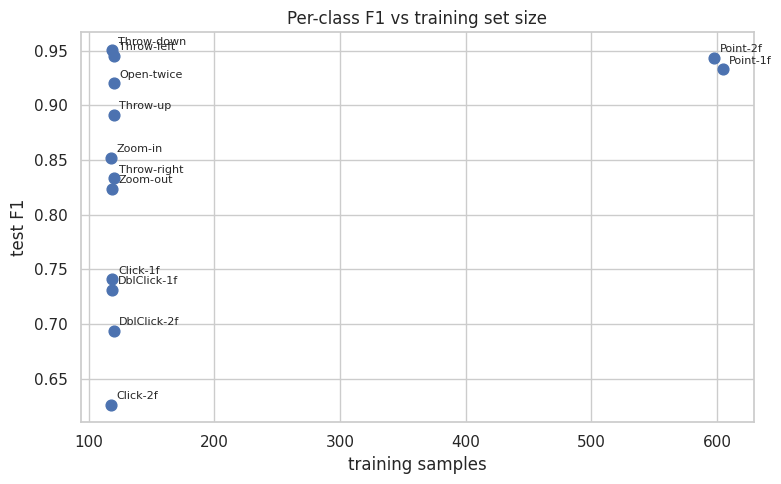

In [22]:
# Per-class F1 vs number of training samples - are rare classes the weak ones?
f1_per_class = final_results['per_class_f1']
support = np.bincount(tr_labels, minlength=13)

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(support, [f1_per_class[g] for g in GESTURE_NAMES], s=60, color="#4C72B0")
for i, g in enumerate(GESTURE_NAMES):
    ax.annotate(g, (support[i], f1_per_class[g]), fontsize=8,
                xytext=(4, 4), textcoords='offset points')
ax.set_xlabel('training samples'); ax.set_ylabel('test F1')
ax.set_title('Per-class F1 vs training set size')
plt.tight_layout(); plt.show()

#### Why does it get them wrong?

Plotting the landmark trajectories of misclassified gestures next to a correct example of the
same class. Index-finger tip (landmark 8) is used because it carries most of the motion in
these gestures.

135 misclassified out of 1101


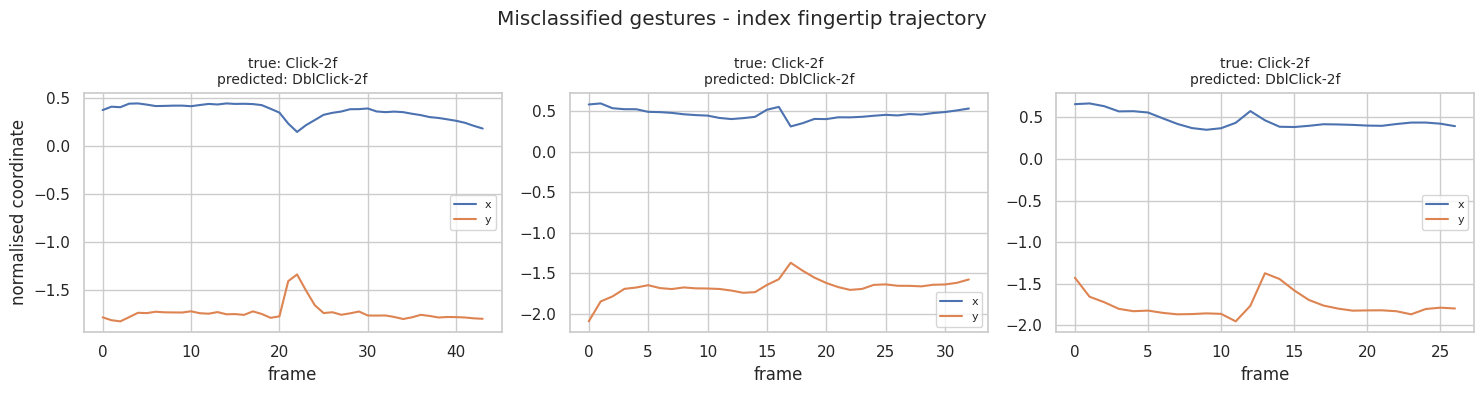

In [23]:
FINGERTIP = 8  # index finger tip -> features 24, 25 in the (21 x 3) layout

wrong = np.where(y_true != y_pred)[0]
print(f"{len(wrong)} misclassified out of {len(y_true)}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, i in zip(axes, wrong[:3]):
    seq = test_seqs[i]
    ax.plot(seq[:, FINGERTIP * 3], label='x')
    ax.plot(seq[:, FINGERTIP * 3 + 1], label='y')
    ax.set_title(f"true: {GESTURE_NAMES[y_true[i]]}\npredicted: {GESTURE_NAMES[y_pred[i]]}",
                 fontsize=10)
    ax.set_xlabel('frame'); ax.legend(fontsize=8)
axes[0].set_ylabel('normalised coordinate')
plt.suptitle('Misclassified gestures - index fingertip trajectory')
plt.tight_layout(); plt.show()

### 11.4 Static vs dynamic gestures

`Point-1f` / `Point-2f` are static (the hand holds a shape), everything else is dynamic.

Static gestures score higher on average (0.938 vs 0.819), but the dynamic average hides a
wide spread (0.626-0.950). The directional gestures - Throw in all four directions,
Open-twice, Zoom - reach 0.83-0.95, on par with the static ones. The average is pulled
down entirely by the Click / DblClick family (0.63-0.74), where the gestures share both
hand shape and movement and differ only in how many times the motion repeats.

So the model handles *direction* and *shape of motion* well; what it struggles with is
*counting repetitions* over time.

          mean    min    max  count
type                               
dynamic  0.819  0.626  0.950     11
static   0.938  0.933  0.943      2


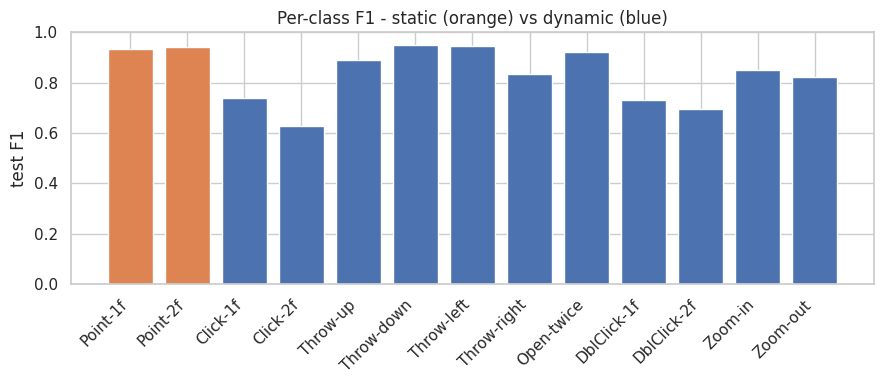

In [24]:
STATIC = ['Point-1f', 'Point-2f']

per_class = final_results['per_class_f1']
rows = [{'gesture': g,
         'type': 'static' if g in STATIC else 'dynamic',
         'f1': per_class[g]} for g in GESTURE_NAMES]
type_df = pd.DataFrame(rows)

print(type_df.groupby('type')['f1'].agg(['mean', 'min', 'max', 'count']).round(3).to_string())

fig, ax = plt.subplots(figsize=(9, 4))
colors = ['#DD8452' if t == 'static' else '#4C72B0' for t in type_df['type']]
ax.bar(type_df['gesture'], type_df['f1'], color=colors)
ax.set_ylabel('test F1'); ax.set_ylim(0, 1)
ax.set_title('Per-class F1 - static (orange) vs dynamic (blue)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.show()

## 12. Save results for the joint comparison


In [25]:
import os, json

os.makedirs("../results", exist_ok=True)
os.makedirs("../results/models", exist_ok=True)

torch.save(final_model.state_dict(), f"../results/models/best_{BEST_ARCH}.pth")

summary = {
    'model': f"{BEST_ARCH}_final",
    'approach': 'landmark sequence (RNN)',
    'accuracy': float(final_results['accuracy']),
    'f1_weighted': float(final_results['f1_weighted']),
    'f1_macro': float(final_results['f1_macro']),
    'inference_ms': float(timing['mean_ms']),
    'parameters': int(count_parameters(final_model)),
    'config': {'architecture': BEST_ARCH, 'hidden': best_hidden,
               'layers': best_layers, 'dropout': best_dropout,
               'T_fixed': best_t, 'velocity_features': USE_VELOCITY},
}

with open("../results/lstm_results.json", "w") as f:
    json.dump(summary, f, indent=2)

exp_df.to_csv("../results/lstm_experiments.csv", index=False)
print(json.dumps(summary, indent=2))

{
  "model": "BiLSTM_final",
  "approach": "landmark sequence (RNN)",
  "accuracy": 0.8773841961852861,
  "f1_weighted": 0.8761391271120692,
  "f1_macro": 0.8372242239710688,
  "inference_ms": 1.8591888701485004,
  "parameters": 674701,
  "config": {
    "architecture": "BiLSTM",
    "hidden": 128,
    "layers": 2,
    "dropout": 0.3,
    "T_fixed": 60,
    "velocity_features": true
  }
}
